In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import missingno as msno

from sklearn.model_selection import train_test_split

In [2]:
FILE_PATH = Path.cwd().parent / "datasets" / "animal_data_dirty1.csv"

In [3]:
df = pd.read_csv(FILE_PATH,sep=';') # NOTE : Seperator is ; 

In [4]:
df.head()

,Animal type,Country,Weight kg,Body Length cm,Gender,Animal code,Latitude,Longitude,Animal name,Observation date,Data compiled by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
2,European bison,Poland,930.0,335.0,male,NaN,52.828845,23.820144,Szefu,01.03.2024,Anne Anthony
3,European bison,Poland,909.0,311.0,not determined,NaN,52.830509,23.826849,NaN,01.03.2024,Anne Anthony
4,European bison™,Poland,581.0,277.0,female,NaN,52.834109,23.807093,NaN,01.03.2024,Anne Anthony


In [5]:
def examine_dataframe(df):
    df.columns = [x.lower().strip().replace(" ","_") for x in df.columns]
    print(f"Dataframe shape : {df.shape}")
    print("-"*100)
    print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-"*100)
    print(f"Column Dtypes: \n{df.dtypes.value_counts()}")
    print("-"*100)
    columns_df = pd.DataFrame({
                'column' : df.columns,
                'dtype' : [x for x in df.dtypes],
                '#unique_values' : [df[x].nunique() for x in df.columns],
                '#non_null_values' : df.notna().sum().tolist() ,
                '#null_values' : df.isna().sum().tolist() ,
                '%null_values' : [f'{x:.2f}' for x in ((df.isna().sum()/df.shape[0])*100).to_list()]
                
        })
    return (columns_df)
    


In [6]:
examine_dataframe(df)

Dataframe shape : (1011, 11)
----------------------------------------------------------------------------------------------------
Memory Usage : 0.35 MB
----------------------------------------------------------------------------------------------------
Column Dtypes: 
object     6
float64    5
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


,column,dtype,#unique_values,#non_null_values,#null_values,%null_values
0,animal_type,object,12,991,20,1.98
1,country,object,14,999,12,1.19
2,weight_kg,float64,195,984,27,2.67
3,body_length_cm,float64,112,984,27,2.67
4,gender,object,3,992,19,1.88
5,animal_code,float64,0,0,1011,100.00
6,latitude,float64,735,913,98,9.69
7,longitude,float64,743,913,98,9.69
8,animal_name,object,10,52,959,94.86
9,observation_date,object,114,1011,0,0.00


## The main aim of this notebook is to practice cleaning on the dataset .

In [7]:
# There seems to have a lot of null values in here , we have to move cautiously when dealing with missing values to check whether they are MAR , MCAR or MCNAR.

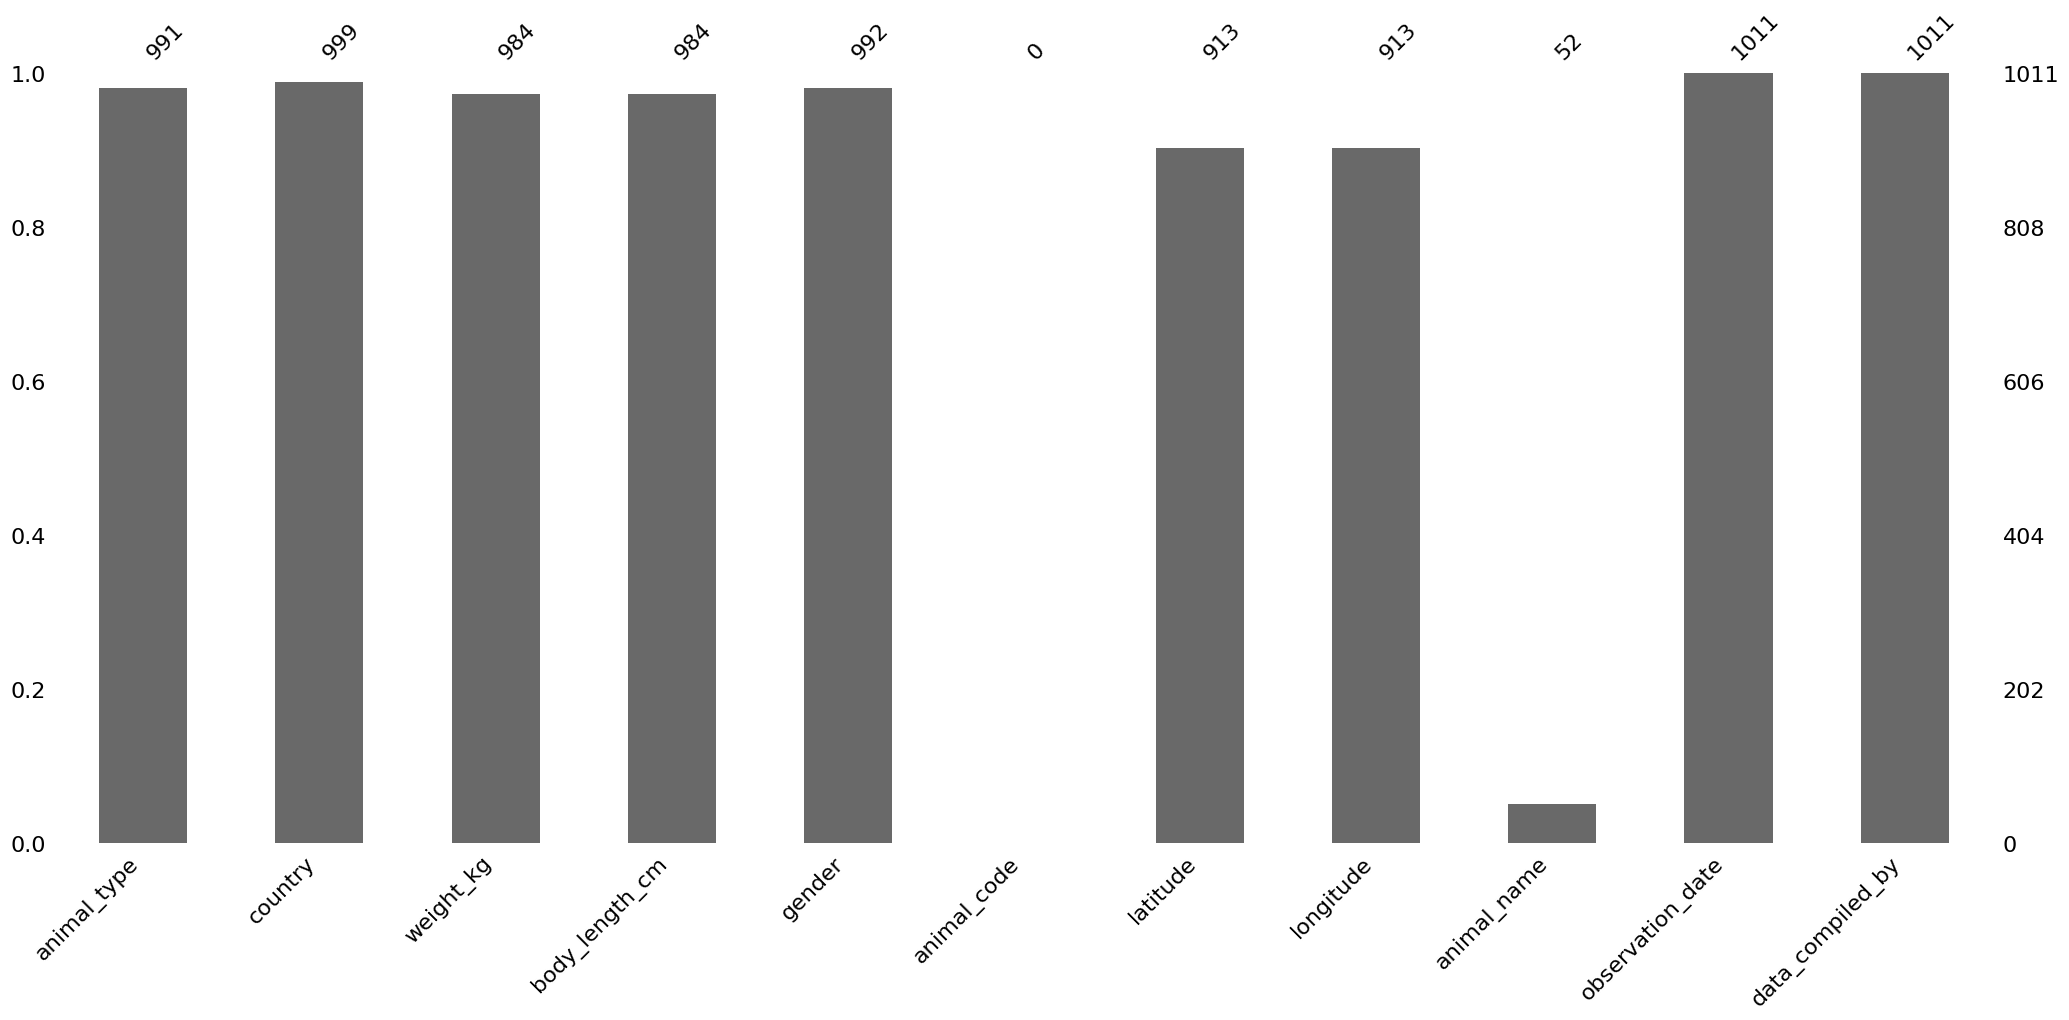

In [8]:
# Let's check whether this missingness is randome or not
msno.bar(df)
plt.show()
# Plot the bar graph which displays us the number of NoN NULL values

### Evaluating NULL values based on Count : 
    Animal code : Completely Missing and cannot be recovered will be forced to drop. 
    Animal name : Again Almost Completely Missing with some 52 values left ( may be dropped ).
>   Rest of the columns shall be handled by various transformations and techniques.

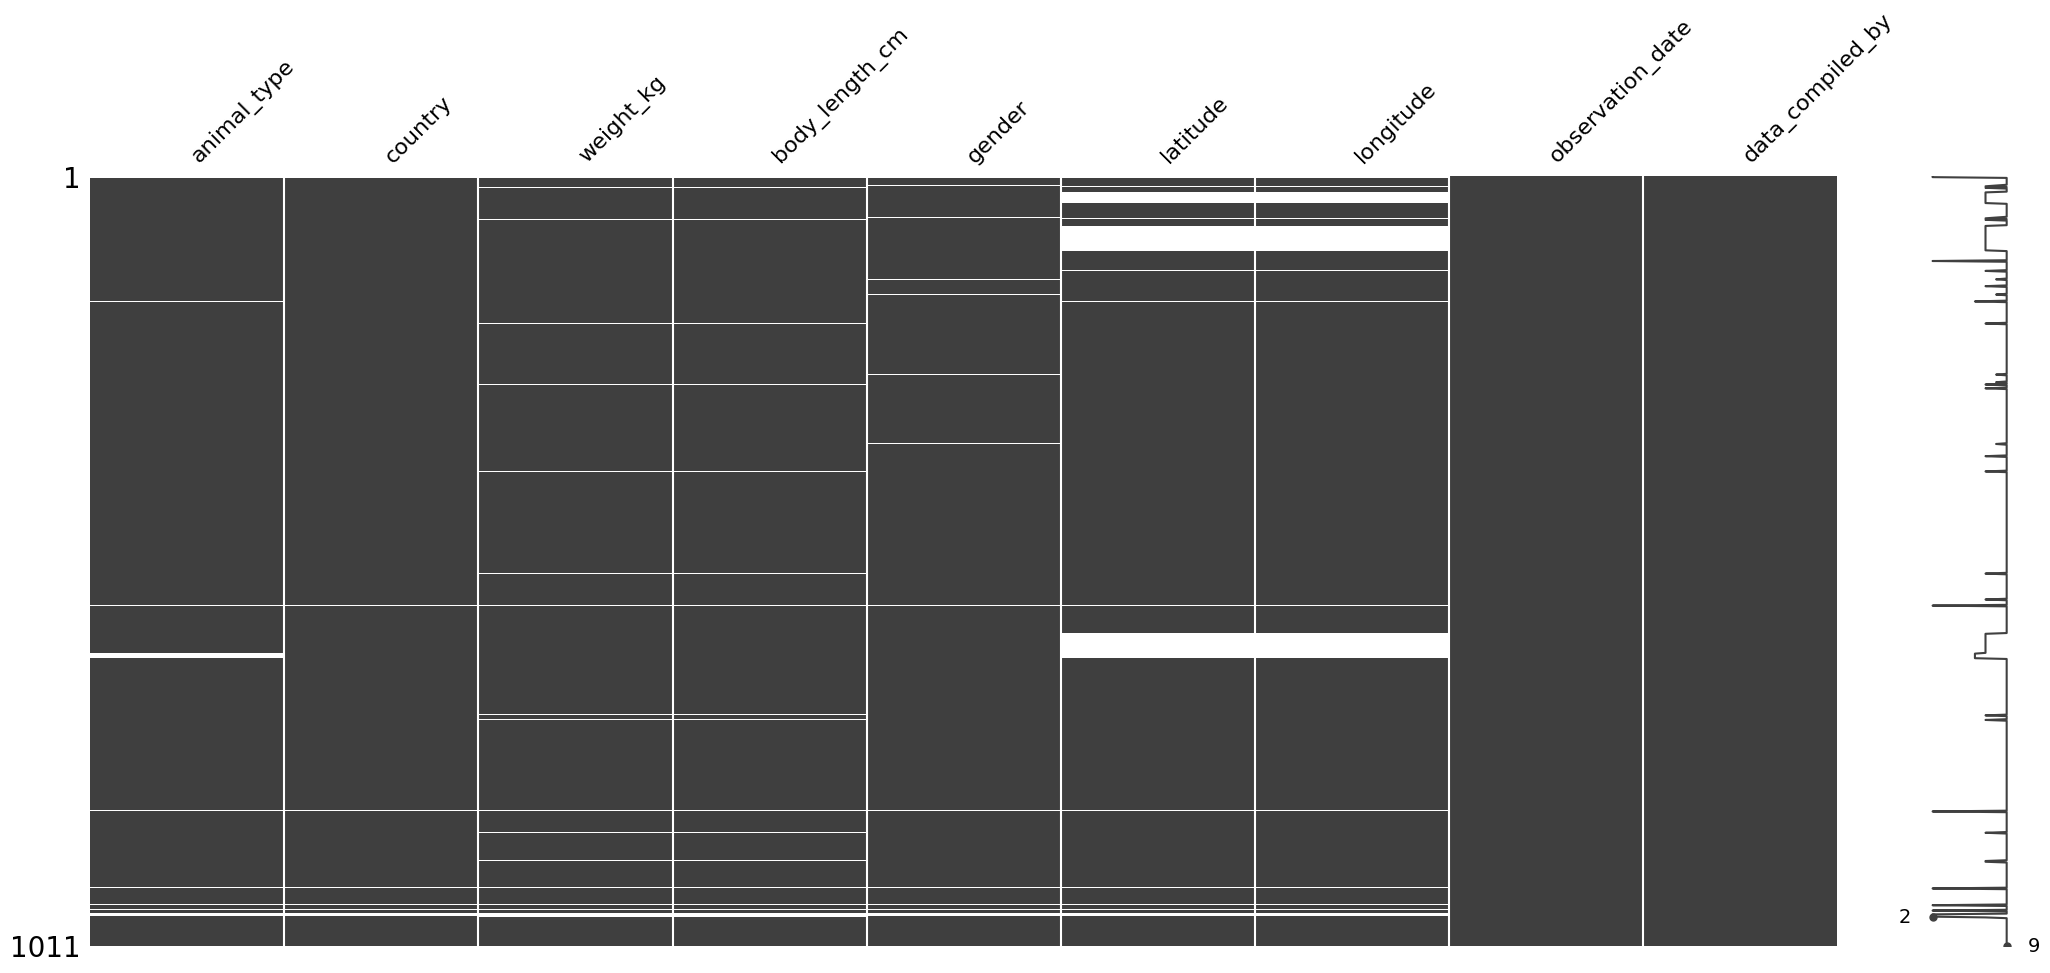

In [18]:
# Now let's actually look for patterns in Null Values by plotting the matrix and then the heatmap.
msno.matrix(df)
plt.show()

### Evaluating the matrix : 
    1. We Clearly see there are some specific lines in the matrix that rows with completely missing values ( the long spikes seen in the chart at right).
       These values are missing with a pattern suggesting something ( need to be investigated).
    2. The pairs : (Weight kg , Body Length cm) and (Latitude , Longitude) both have missing values together (correlated).
    3. Animal type and gender have some missing values independently with no pattern.
    4. Animal Code is completely missng and in Animal name we barely have any values. 

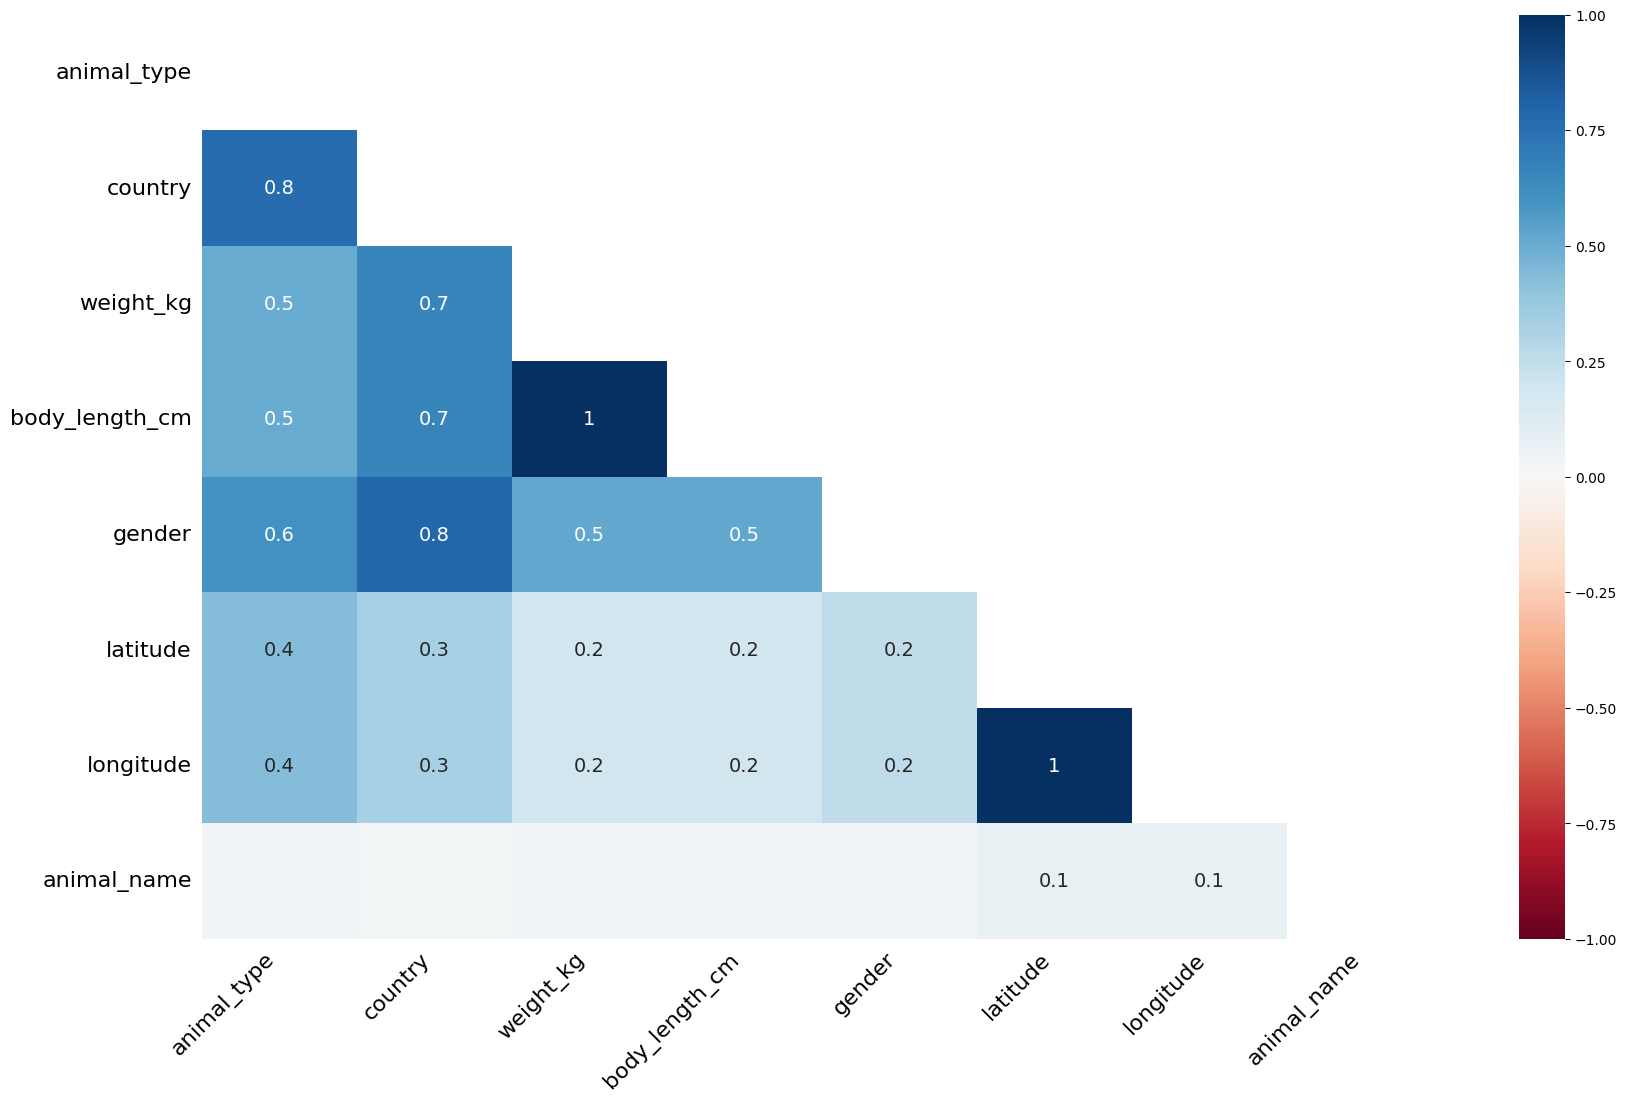

In [10]:
msno.heatmap(df)
plt.show()

In [11]:
# As suspected there is complete correlation between the pairs we discussed .
# One from each pair must be removed before model training as the other column in the pair is redundant and will cause MultiCollinearity in Linear MODELs.

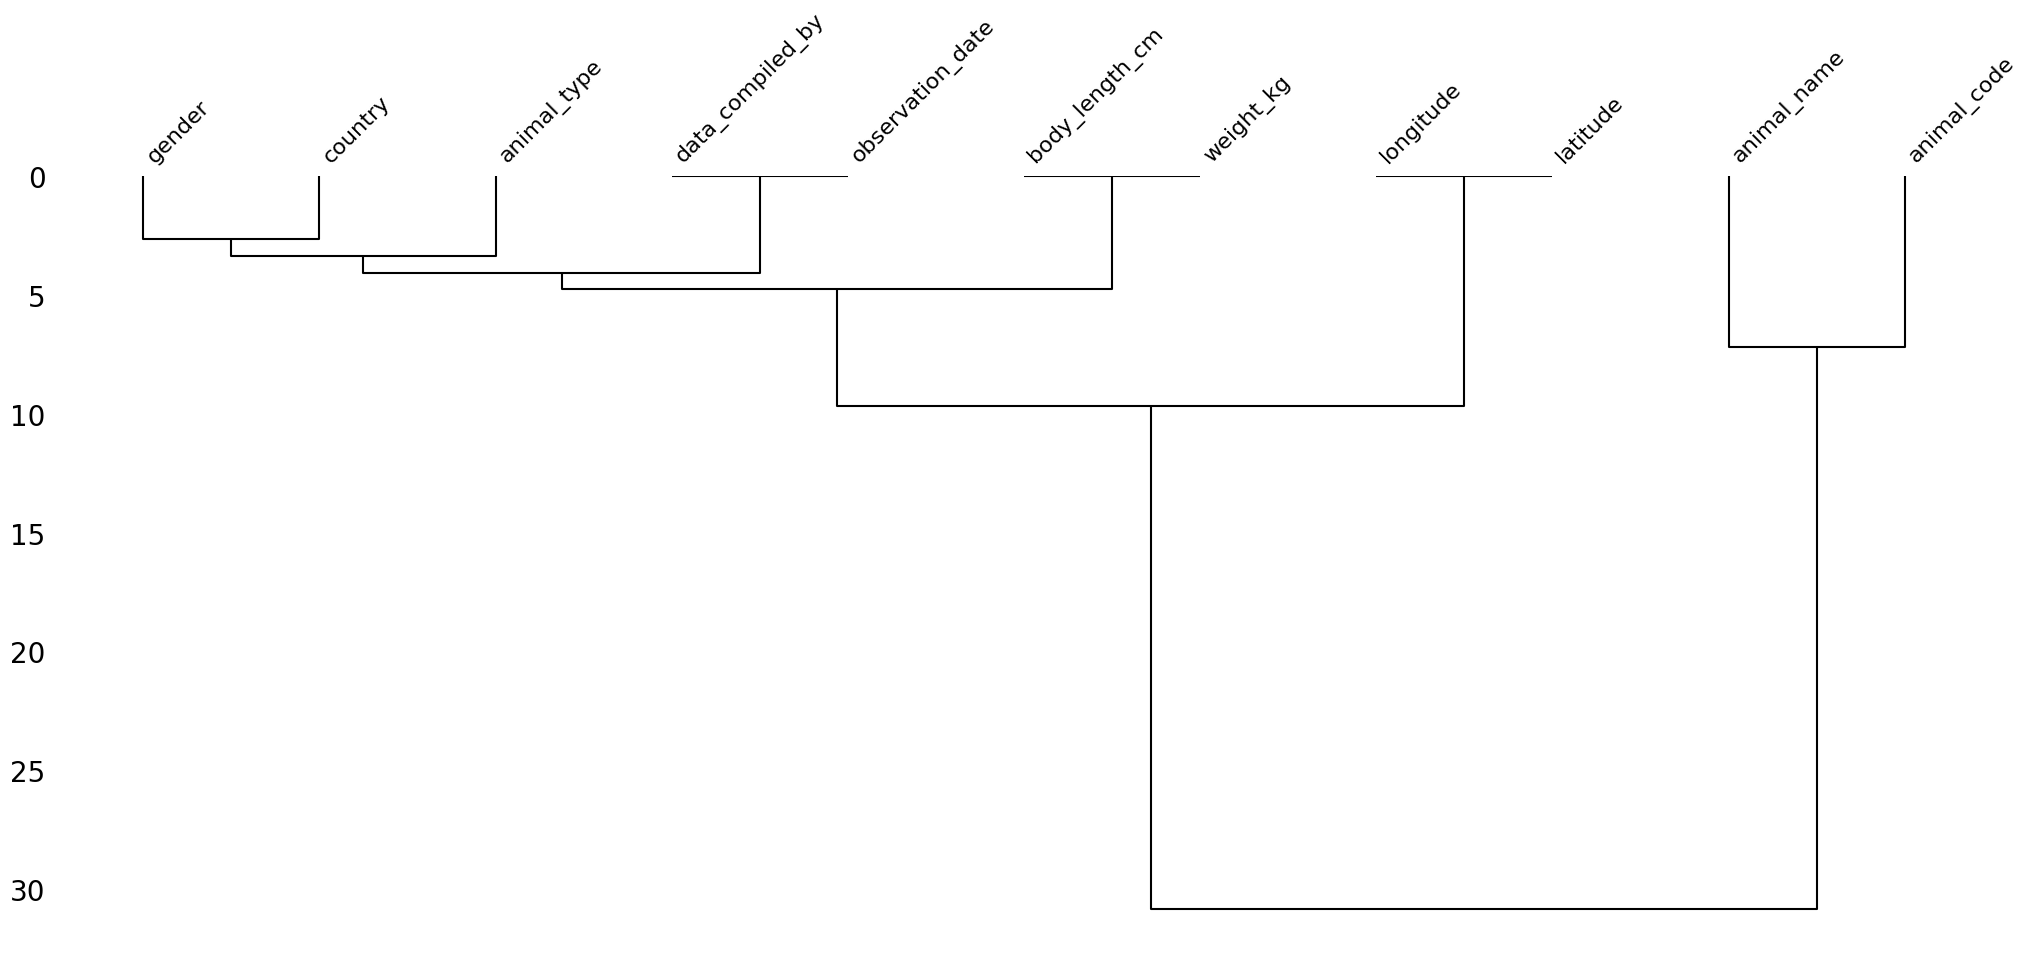

In [12]:
msno.dendrogram(df)
plt.show()

In [13]:
# Before Moving forward i Will remove the Completely missing columns
df = df.drop(columns=['animal_code','animal_name'])

In [14]:
# Now let's one by one analyze the complete dataframe where we have columns missing with a pattern

In [ ]:
#CASE 1 : All values are missing completely uptil latitude
val_missing_completely_cols = ['animal_type', 'country', 'weight_kg', 'body_length_cm', 'gender','latitude', 'longitude']
df[df[val_missing_completely_cols].isna().all(axis=1)]
# These are the columns where we had values misisng compleletely 
# If you look closely these values are missing on a specific sequential order of date and is compiled by James Johnson
# We will drop this rows as there is really no way to fix these cols tbh

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson
563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.04.2024,James Johnson
833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.05.2024,James Johnson
934,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.06.2024,James Johnson
956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.07.2024,James Johnson
963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.08.2024,James Johnson
968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.13.2024,James Johnson
969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.14.2024,James Johnson


In [38]:
# A total of 12 rows missing from James Johnson 
# This data is not a normal dataset but a log of Time-Series Analysis by different people overtime

In [28]:
# CASE 2 : Data missing in pairs
pair_1 = ['longitude','latitude']
pair_2 = ['weight_kg','body_length_cm']

In [37]:
df[df[pair_1].isna().all(axis=1)].head() # A total of 98 rows missing from different people

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
13,red squirrel,Poland,0.333,21.0,male,NaN,NaN,01.03.2024,Anne Anthony
21,red squirrel,Germany,0.294,19.0,male,NaN,NaN,01.03.2024,Bob Bobson
22,red squirrel,Germany,0.250,19.0,female,NaN,NaN,01.03.2024,Bob Bobson


In [ ]:
df[df[pair_2].isna().all(axis=1)].head() # Total of 27 rows missing in total

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
15,red squirrel,Poland,NaN,NaN,male,52.241177,21.052873,01.03.2024,Anne Anthony
57,red squirrel,Poland,NaN,NaN,male,52.241177,21.052873,01.03.2024,Anne Anthony
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson


In [39]:
# CASE 3 : Column missing values without a pattern

In [42]:
df[df['animal_type'].isna()].head()

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson
164,NaN,Austria,0.263,22.0,male,NaN,NaN,05.03.2024,Bob Bobson
563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.04.2024,James Johnson


In [43]:
# Total of 20 rows missing and suprisinglt these rows are missing along with (longitude,latitude) and is a subset of there missing rows.

In [46]:
df[df['gender'].isna()].head() 

,animal_type,country,weight_kg,body_length_cm,gender,latitude,longitude,observation_date,data_compiled_by
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.01.2024,James Johnson
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.02.2024,James Johnson
12,red squirrel,Poland,0.34,21.0,NaN,52.240284,21.051948,01.03.2024,Anne Anthony
54,red squirrel,Poland,0.34,21.0,NaN,52.240284,21.051948,01.03.2024,Anne Anthony
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03.03.2024,James Johnson


In [47]:
# Total of 19 rows missing without having a any pattern with any other columm's missingness (maybe MCAR)